In [29]:
import pandas as pd
import sqlite3

conn = sqlite3.connect('health_eda.db')

occupation_df = pd.read_sql_query('SELECT * FROM occupation_summary', conn)
bmi_df = pd.read_sql_query('SELECT * FROM bmi_summary', conn)
gender_df = pd.read_sql_query('SELECT * FROM gender_summary', conn)
age_df = pd.read_sql_query('SELECT * FROM age_summary', conn)
heart_summary_df = pd.read_sql_query('SELECT * FROM heart_summary', conn)
smoking_df = pd.read_sql_query('SELECT * FROM smoking_summary', conn)
age_heart_df = pd.read_sql_query('SELECT * FROM age_heart_summary', conn)
diabetes_df = pd.read_sql_query('SELECT * FROM diabetes_summary', conn)

conn.close()
print('All tables loaded successfully!')

All tables loaded successfully!


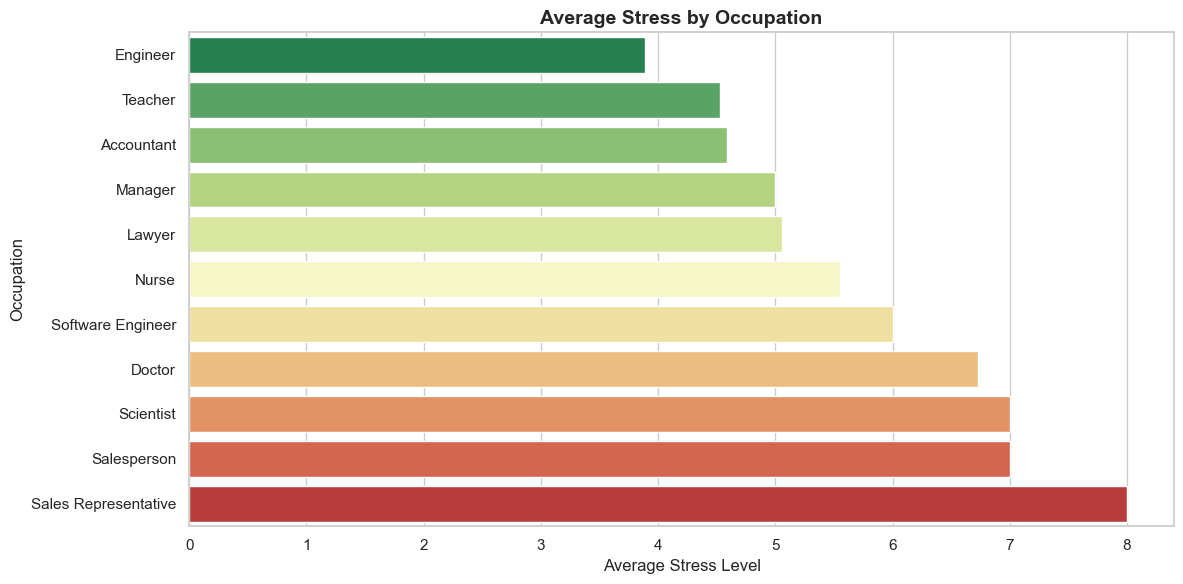

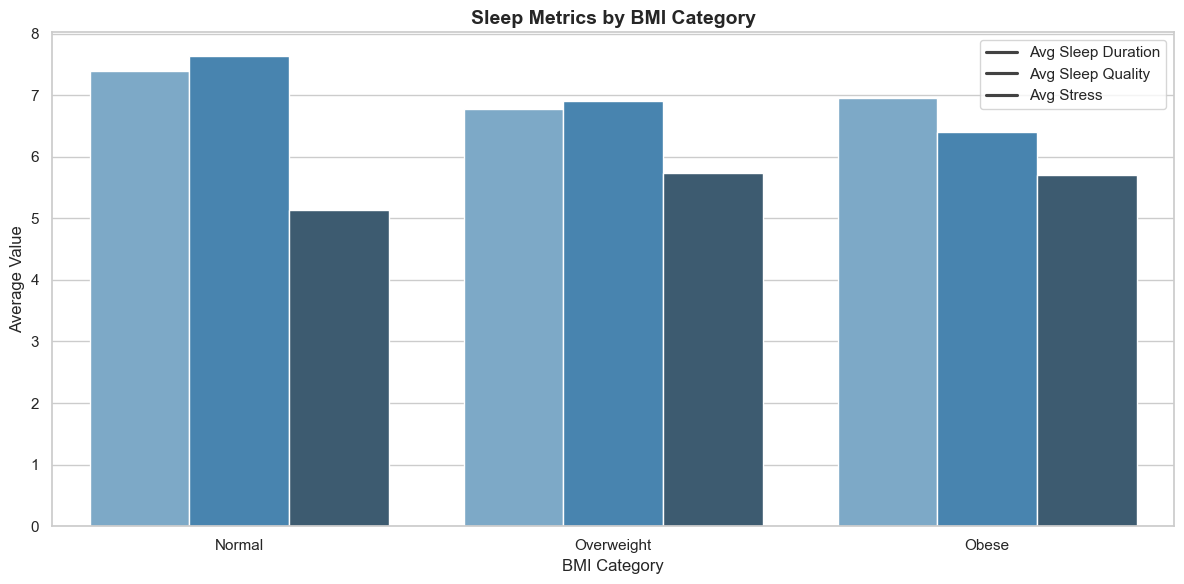

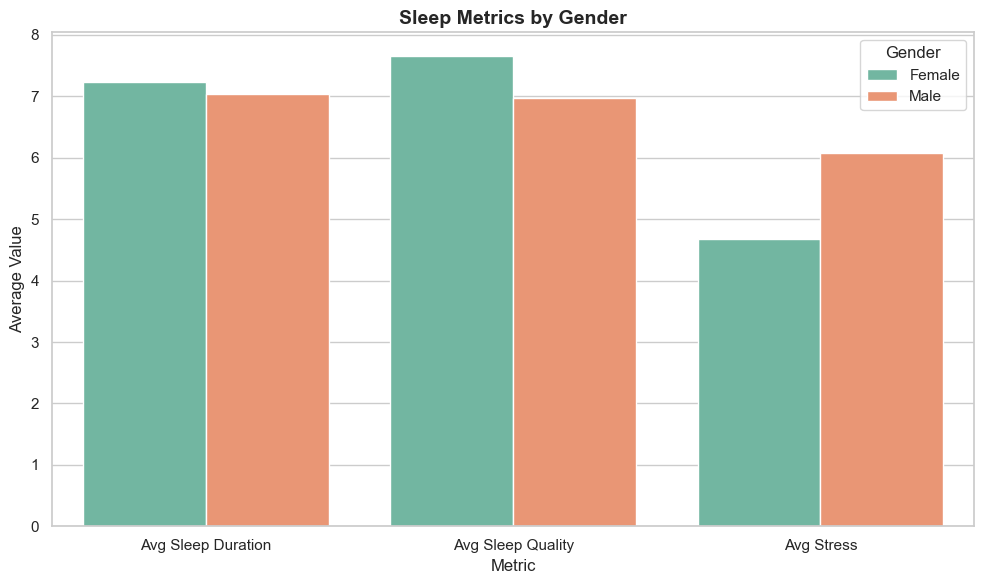

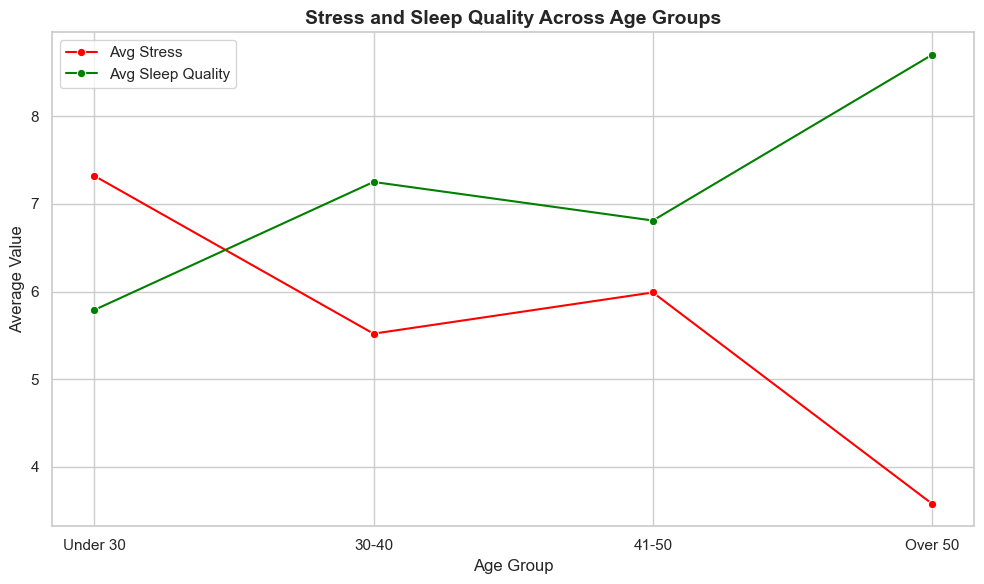

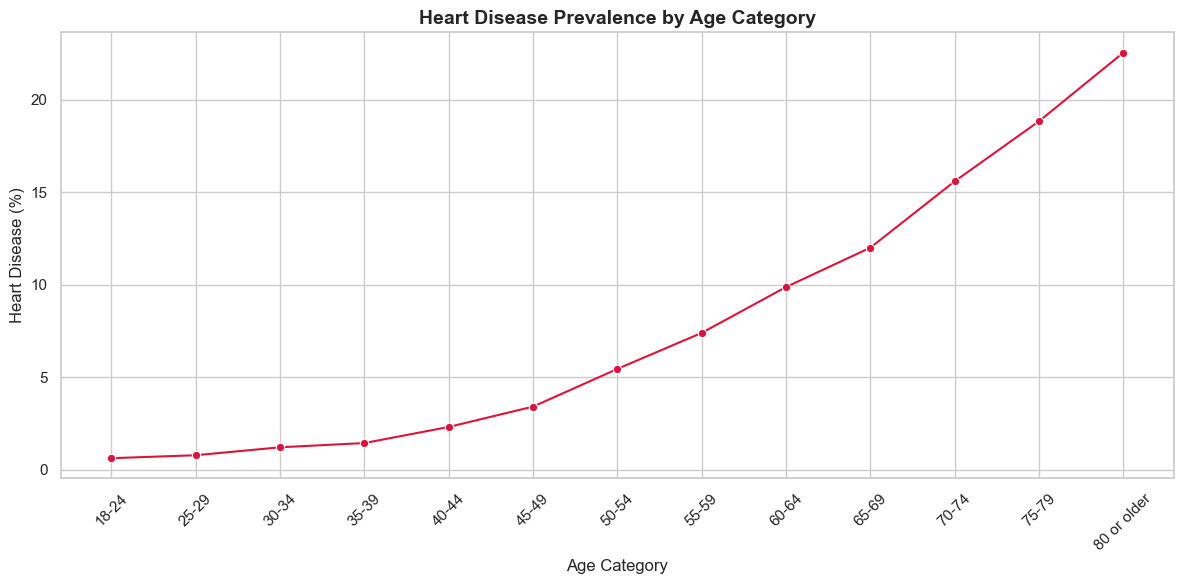

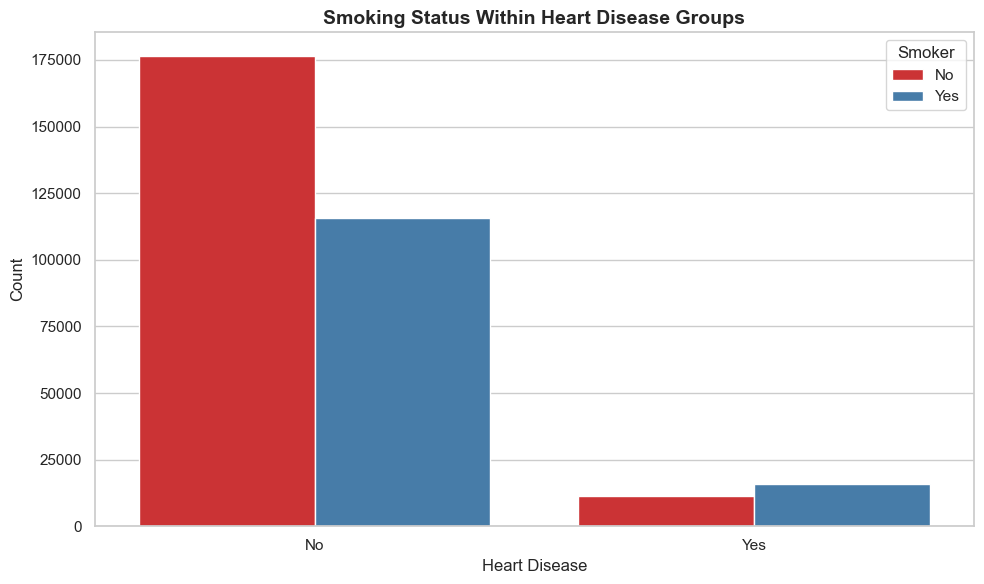

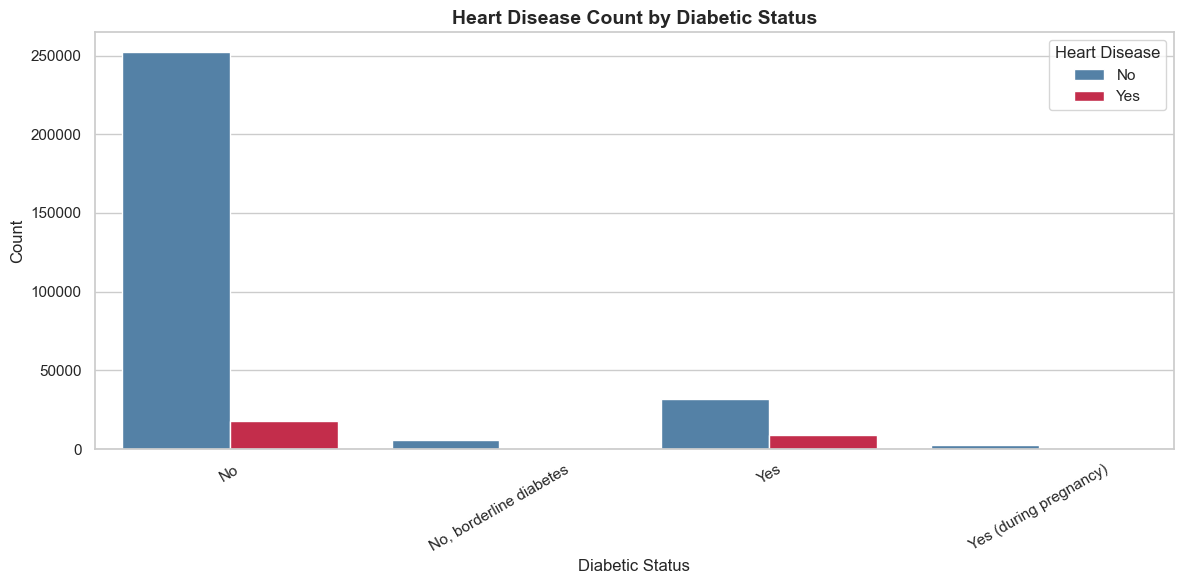

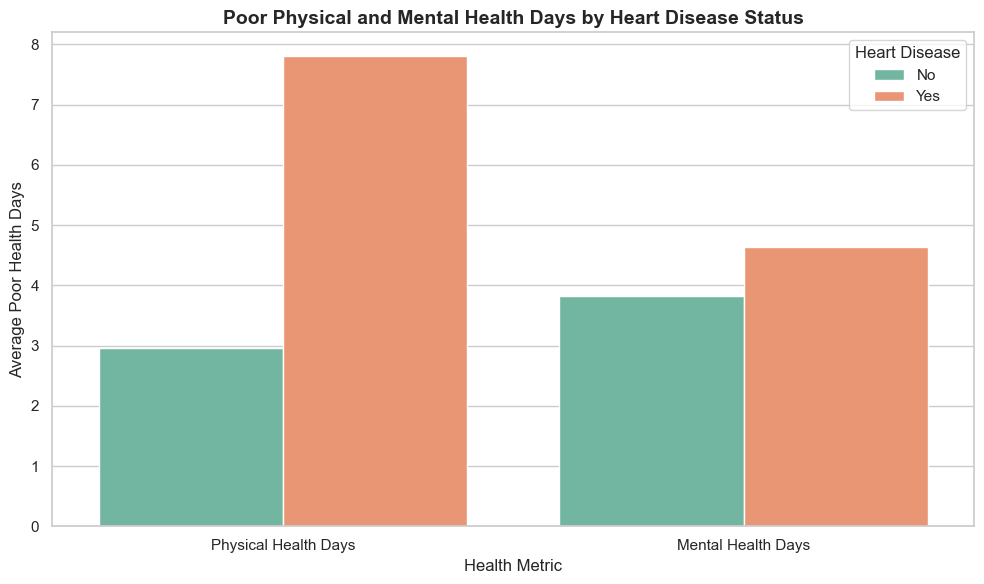

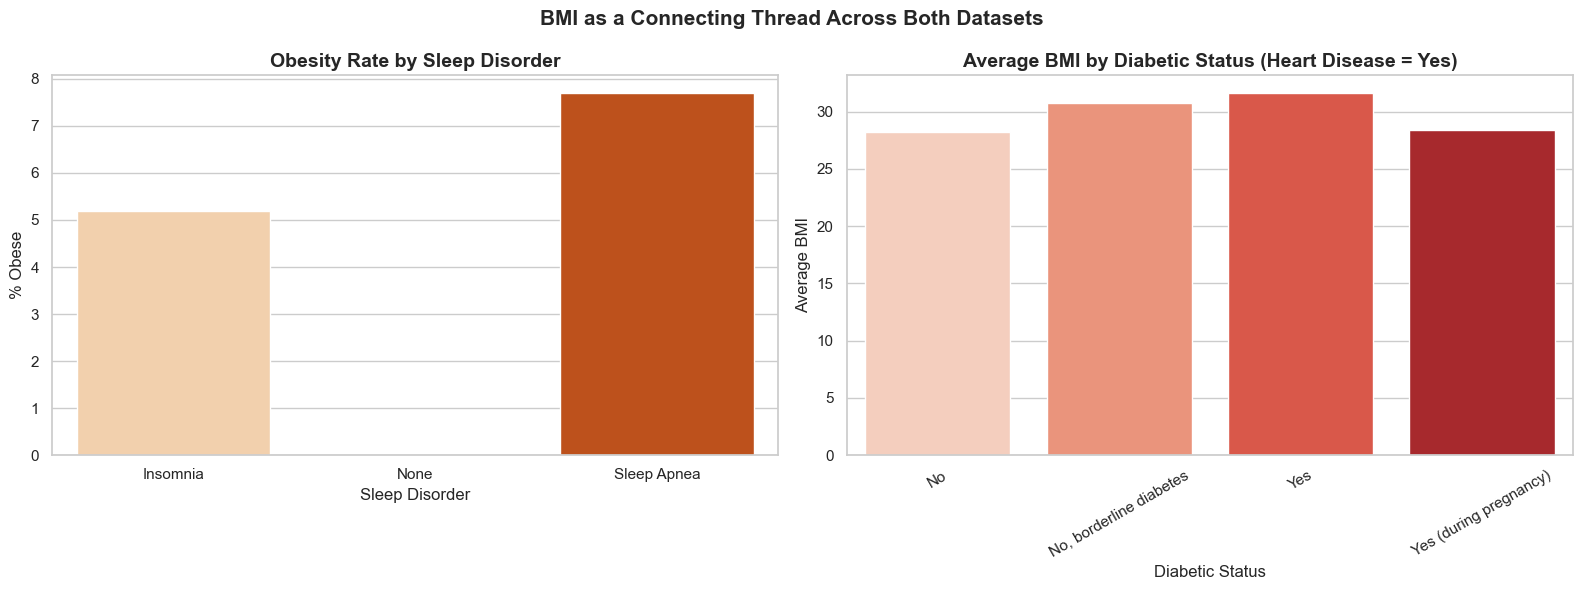

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Global style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Chart 1: Occupation Risk Profile
plt.figure(figsize=(12, 6))
occupation_sorted = occupation_df.sort_values('avg_stress')
sns.barplot(data=occupation_sorted, x='avg_stress', y='Occupation', hue='Occupation', palette='RdYlGn_r', legend=False)
plt.title('Average Stress by Occupation')
plt.xlabel('Average Stress Level')
plt.ylabel('Occupation')
plt.tight_layout()
plt.show()

# Chart 2: BMI and Sleep
bmi_order = ['Normal', 'Overweight', 'Obese']
bmi_melted = bmi_df.melt(id_vars='bmi_category', value_vars=['avg_sleep', 'avg_quality', 'avg_stress'], var_name='metric', value_name='value')

plt.figure(figsize=(12, 6))
sns.barplot(data=bmi_melted, x='bmi_category', y='value', hue='metric', order=bmi_order, palette='Blues_d')
plt.title('Sleep Metrics by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Average Value')
plt.legend(labels=['Avg Sleep Duration', 'Avg Sleep Quality', 'Avg Stress'])
plt.tight_layout()
plt.show()

# Chart 3: Gender Differences
gender_melted = gender_df.melt(id_vars='Gender', value_vars=['avg_sleep', 'avg_quality', 'avg_stress'], var_name='metric', value_name='value')

plt.figure(figsize=(10, 6))
sns.barplot(data=gender_melted, x='metric', y='value', hue='Gender', palette='Set2')
plt.title('Sleep Metrics by Gender')
plt.xlabel('Metric')
plt.ylabel('Average Value')
plt.xticks(ticks=[0, 1, 2], labels=['Avg Sleep Duration', 'Avg Sleep Quality', 'Avg Stress'])
plt.tight_layout()
plt.show()

# Chart 4: Age Group and Sleep Quality
age_order = ['Under 30', '30-40', '41-50', 'Over 50']

plt.figure(figsize=(10, 6))
sns.lineplot(data=age_df.set_index('age_group').loc[age_order], y='avg_stress', x=age_order, marker='o', label='Avg Stress', color='red')
sns.lineplot(data=age_df.set_index('age_group').loc[age_order], y='avg_quality', x=age_order, marker='o', label='Avg Sleep Quality', color='green')
plt.title('Stress and Sleep Quality Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Average Value')
plt.legend()
plt.tight_layout()
plt.show()

# Chart 5: Age and Heart Disease Prevalence
age_order_heart = ['18-24','25-29','30-34','35-39','40-44','45-49','50-54','55-59','60-64','65-69','70-74','75-79','80 or older']
age_heart_df['AgeCategory'] = pd.Categorical(age_heart_df['AgeCategory'], categories=age_order_heart, ordered=True)
age_heart_df = age_heart_df.sort_values('AgeCategory')

plt.figure(figsize=(12, 6))
sns.lineplot(data=age_heart_df, x='AgeCategory', y='heart_disease_pct', marker='o', color='crimson')
plt.title('Heart Disease Prevalence by Age Category')
plt.xlabel('Age Category')
plt.ylabel('Heart Disease (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 6: Smoking and Heart Disease
plt.figure(figsize=(10, 6))
sns.barplot(data=smoking_df, x='HeartDisease', y='count', hue='Smoking', palette='Set1')
plt.title('Smoking Status Within Heart Disease Groups')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.legend(title='Smoker')
plt.tight_layout()
plt.show()

# Chart 7: Diabetes and Heart Disease
plt.figure(figsize=(12, 6))
sns.barplot(data=diabetes_df, x='Diabetic', y='count', hue='HeartDisease', palette={'No': 'steelblue', 'Yes': 'crimson'})
plt.title('Heart Disease Count by Diabetic Status')
plt.xlabel('Diabetic Status')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

# Chart 8: Physical and Mental Health Days
health_melted = heart_summary_df.melt(id_vars='HeartDisease', value_vars=['avg_physical_health', 'avg_mental_health'], var_name='metric', value_name='value')

plt.figure(figsize=(10, 6))
sns.barplot(data=health_melted, x='metric', y='value', hue='HeartDisease', palette='Set2')
plt.title('Poor Physical and Mental Health Days by Heart Disease Status')
plt.xlabel('Health Metric')
plt.ylabel('Average Poor Health Days')
plt.xticks(ticks=[0, 1], labels=['Physical Health Days', 'Mental Health Days'])
plt.legend(title='Heart Disease')
plt.tight_layout()
plt.show()

# Chart 9: BMI Across Sleep Disorder and Diabetic Groups
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sleep_bmi = sleep_df.groupby('sleep_disorder').agg(avg_bmi=('bmi_category', lambda x: (x == 'Obese').sum() / len(x) * 100)).reset_index()
sns.barplot(data=sleep_bmi, x='sleep_disorder', y='avg_bmi', hue='sleep_disorder', palette='Oranges', legend=False, ax=axes[0])
axes[0].set_title('Obesity Rate by Sleep Disorder')
axes[0].set_xlabel('Sleep Disorder')
axes[0].set_ylabel('% Obese')

diabetes_bmi = diabetes_df[diabetes_df['HeartDisease'] == 'Yes'].copy()
sns.barplot(data=diabetes_bmi, x='Diabetic', y='avg_bmi', hue='Diabetic', palette='Reds', legend=False, ax=axes[1])
axes[1].set_title('Average BMI by Diabetic Status (Heart Disease = Yes)')
axes[1].set_xlabel('Diabetic Status')
axes[1].set_ylabel('Average BMI')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('BMI as a Connecting Thread Across Both Datasets', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

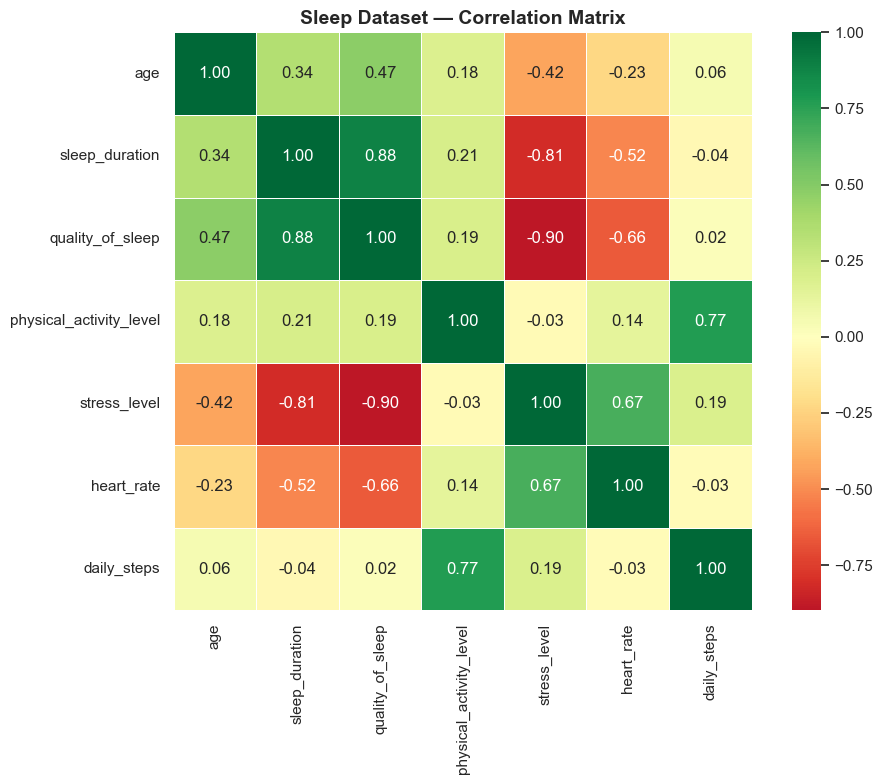

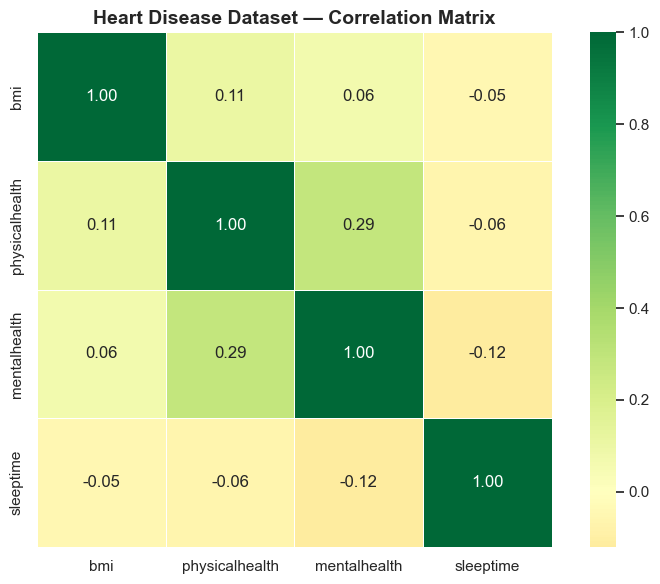

In [ ]:
# Sleep Dataset Correlation Matrix
# Select only numeric columns
sleep_numeric = sleep_df[['age', 'sleep_duration', 'quality_of_sleep', 
                           'physical_activity_level', 'stress_level', 
                           'heart_rate', 'daily_steps']]

# Calculate correlation matrix
sleep_corr = sleep_numeric.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(sleep_corr, annot=True, fmt='.2f', cmap='RdYlGn', 
            center=0, square=True, linewidths=0.5)
plt.title('Sleep Dataset — Correlation Matrix')
plt.tight_layout()
plt.show()

# Heart Disease Dataset Correlation Matrix
# Select only numeric columns
heart_numeric = heart_df[['bmi', 'physicalhealth', 'mentalhealth', 'sleeptime']]

# Calculate correlation matrix
heart_corr = heart_numeric.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heart_corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5)
plt.title('Heart Disease Dataset — Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# Pearson Correlation Test - Stress vs Sleep Quality
corr, p_value = stats.pearsonr(sleep_df['stress_level'], sleep_df['quality_of_sleep'])

print('--- Pearson Correlation Test ---')
print(f'Correlation: {corr:.4f}')
print(f'P-value: {p_value:.10f}')
if p_value < 0.05:
    print('Result: Statistically significant — stress level and sleep quality are strongly correlated')
else:
    print('Result: Not statistically significant')

# Chi-Squared Test - Smoking and Heart Disease
smoking_contingency = pd.crosstab(heart_df['smoking'], heart_df['heartdisease'])
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(smoking_contingency)

print('\n--- Chi-Squared Test: Smoking and Heart Disease ---')
print(f'Chi-squared statistic: {chi2:.4f}')
print(f'P-value: {p_value_chi2:.10f}')
print(f'Degrees of freedom: {dof}')
if p_value_chi2 < 0.05:
    print('Result: Statistically significant — smoking and heart disease are not independent')
else:
    print('Result: Not statistically significant')

# Chi-Squared Test - Diabetes and Heart Disease
diabetes_contingency = pd.crosstab(heart_df['diabetic'], heart_df['heartdisease'])
chi2_diab, p_value_diab, dof_diab, expected_diab = stats.chi2_contingency(diabetes_contingency)

print('\n--- Chi-Squared Test: Diabetes and Heart Disease ---')
print(f'Chi-squared statistic: {chi2_diab:.4f}')
print(f'P-value: {p_value_diab:.10f}')
print(f'Degrees of freedom: {dof_diab}')
if p_value_diab < 0.05:
    print('Result: Statistically significant — diabetes status and heart disease are not independent')
else:
    print('Result: Not statistically significant')

--- Pearson Correlation Test ---
Correlation: -0.8988
P-value: 0.0000000000
Result: Statistically significant — stress level and sleep quality are strongly correlated

--- Chi-Squared Test: Smoking and Heart Disease ---
Chi-squared statistic: 3713.0331
P-value: 0.0000000000
Degrees of freedom: 1
Result: Statistically significant — smoking and heart disease are not independent

--- Chi-Squared Test: Diabetes and Heart Disease ---
Chi-squared statistic: 10959.8613
P-value: 0.0000000000
Degrees of freedom: 3
Result: Statistically significant — diabetes status and heart disease are not independent



--- Logistic Regression ---
Accuracy: 0.8800
              precision    recall  f1-score   support

    Insomnia       0.74      0.88      0.80        16
        None       0.93      0.93      0.93        43
 Sleep Apnea       0.92      0.75      0.83        16

    accuracy                           0.88        75
   macro avg       0.86      0.85      0.85        75
weighted avg       0.89      0.88      0.88        75


--- Random Forest ---
Accuracy: 0.8800
              precision    recall  f1-score   support

    Insomnia       0.72      0.81      0.76        16
        None       0.95      0.98      0.97        43
 Sleep Apnea       0.85      0.69      0.76        16

    accuracy                           0.88        75
   macro avg       0.84      0.83      0.83        75
weighted avg       0.88      0.88      0.88        75



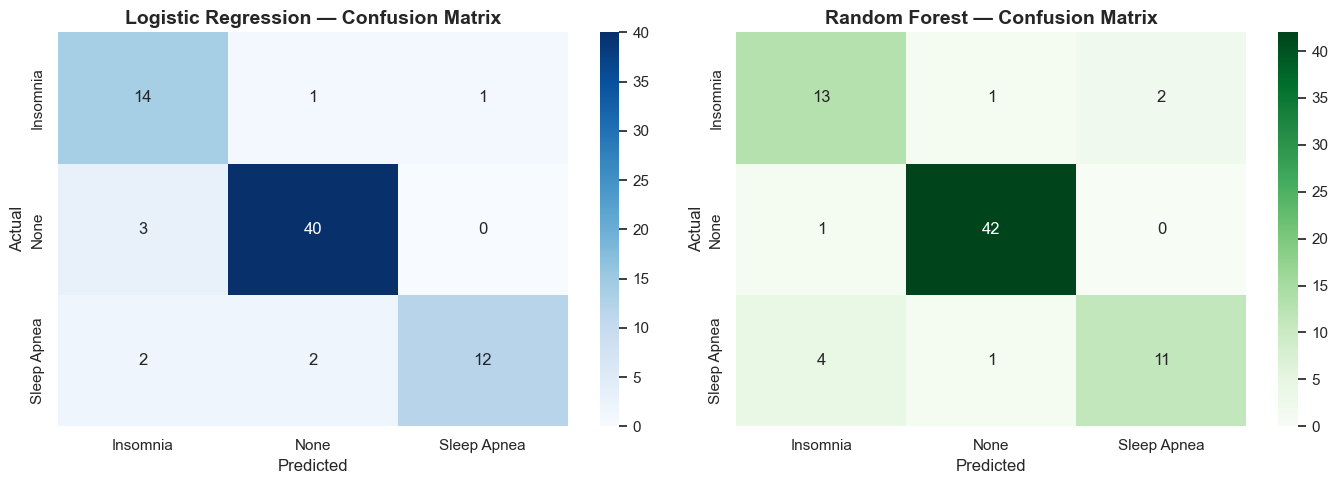

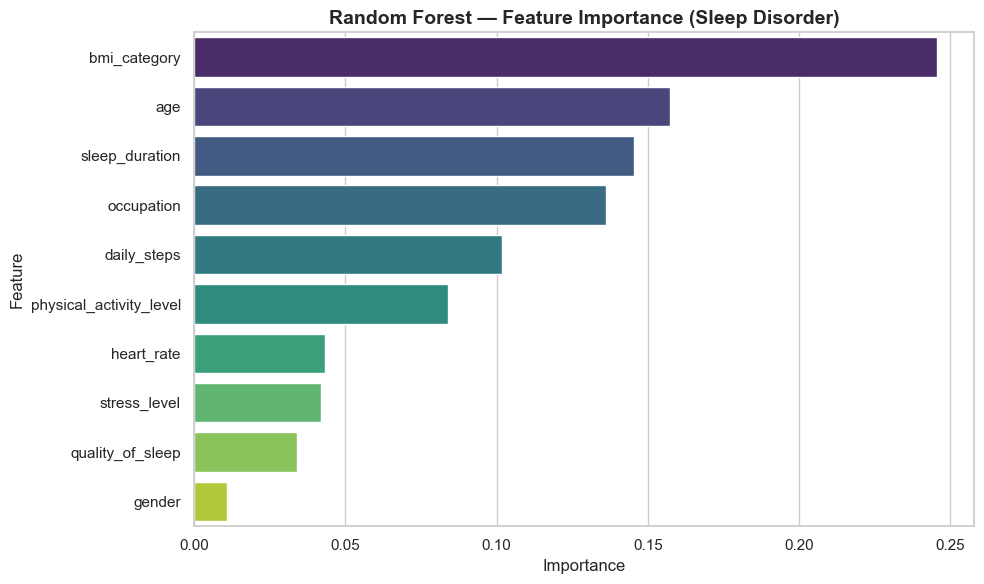

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scale Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
lr_model = LogisticRegression(max_iter=5000, random_state=30)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print('\n--- Logistic Regression ---')
print(f'Accuracy: {accuracy_score(y_test, lr_pred):.4f}')
print(classification_report(y_test, lr_pred, target_names=['Insomnia', 'None', 'Sleep Apnea']))

# Random Forest (doesn't need scaling)
rf_model = RandomForestClassifier(n_estimators=100, random_state=30)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print('\n--- Random Forest ---')
print(f'Accuracy: {accuracy_score(y_test, rf_pred):.4f}')
print(classification_report(y_test, rf_pred, target_names=['Insomnia', 'None', 'Sleep Apnea']))

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d',
            xticklabels=['Insomnia', 'None', 'Sleep Apnea'],
            yticklabels=['Insomnia', 'None', 'Sleep Apnea'],
            cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression — Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d',
            xticklabels=['Insomnia', 'None', 'Sleep Apnea'],
            yticklabels=['Insomnia', 'None', 'Sleep Apnea'],
            cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest — Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Feature Importance (Random Forest)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', 
            hue='feature', palette='viridis', legend=False)
plt.title('Random Forest — Feature Importance (Sleep Disorder)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Odds Ratio Analysis - Heart Disease Risk Factors 

# Smoking odds ratio
smoking_table = pd.crosstab(heart_df['smoking'], heart_df['heartdisease'])
print('Smoking contingency table:')
print(smoking_table)

odds_smoking = (smoking_table.loc['Yes', 'Yes'] * smoking_table.loc['No', 'No']) / \
               (smoking_table.loc['Yes', 'No'] * smoking_table.loc['No', 'Yes'])

print(f'\nSmokers are {odds_smoking:.2f}x more likely to have heart disease than non-smokers')

# Diabetes odds ratio
diabetes_table = pd.crosstab(heart_df['diabetic'], heart_df['heartdisease'])
print('\nDiabetes contingency table:')
print(diabetes_table)

odds_diabetes = (diabetes_table.loc['Yes', 'Yes'] * diabetes_table.loc['No', 'No']) / \
                (diabetes_table.loc['Yes', 'No'] * diabetes_table.loc['No', 'Yes'])

print(f'\nDiabetics are {odds_diabetes:.2f}x more likely to have heart disease than non-diabetics')

# Physical activity odds ratio
activity_table = pd.crosstab(heart_df['physicalactivity'], heart_df['heartdisease'])
print('\nPhysical activity contingency table:')
print(activity_table)

odds_activity = (activity_table.loc['No', 'Yes'] * activity_table.loc['Yes', 'No']) / \
                (activity_table.loc['No', 'No'] * activity_table.loc['Yes', 'Yes'])

print(f'\nPhysically inactive people are {odds_activity:.2f}x more likely to have heart disease than active people')

# Alcohol drinking odds ratio
alcohol_table = pd.crosstab(heart_df['alcoholdrinking'], heart_df['heartdisease'])

odds_alcohol = (alcohol_table.loc['Yes', 'Yes'] * alcohol_table.loc['No', 'No']) / \
               (alcohol_table.loc['Yes', 'No'] * alcohol_table.loc['No', 'Yes'])

print(f'\nHeavy drinkers are {odds_alcohol:.2f}x more likely to have heart disease than non-drinkers')

Smoking contingency table:
heartdisease      No    Yes
smoking                    
No            176551  11336
Yes           115871  16037

Smokers are 2.16x more likely to have heart disease than non-smokers

Diabetes contingency table:
heartdisease                 No    Yes
diabetic                              
No                       252134  17519
No, borderline diabetes    5992    789
Yes                       31845   8957
Yes (during pregnancy)     2451    108

Diabetics are 4.05x more likely to have heart disease than non-diabetics

Physical activity contingency table:
heartdisease          No    Yes
physicalactivity               
No                 61954   9884
Yes               230468  17489

Physically inactive people are 2.10x more likely to have heart disease than active people

Heavy drinkers are 0.57x more likely to have heart disease than non-drinkers


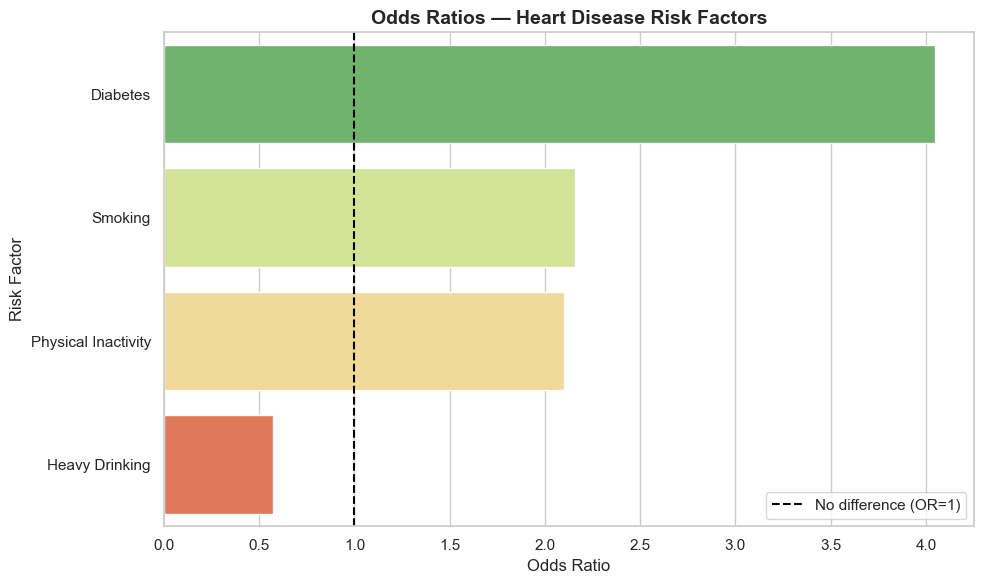

In [ ]:
# Odds Ratio Visualisation
odds_df = pd.DataFrame({
    'risk_factor': ['Diabetes', 'Smoking', 'Physical Inactivity', 'Heavy Drinking'],
    'odds_ratio': [4.05, 2.16, 2.10, 0.57]
})

plt.figure(figsize=(10, 6))
sns.barplot(data=odds_df.sort_values('odds_ratio', ascending=False),
            x='odds_ratio', y='risk_factor',
            hue='risk_factor', palette='RdYlGn_r', legend=False)
plt.axvline(x=1, color='black', linestyle='--', linewidth=1.5, label='No difference (OR=1)')
plt.title('Odds Ratios — Heart Disease Risk Factors')
plt.xlabel('Odds Ratio')
plt.ylabel('Risk Factor')
plt.legend()
plt.tight_layout()
plt.show()